In [1]:
#!/bin/bash
!curl -L -o ../flight-delay.zip\
https://www.kaggle.com/api/v1/datasets/download/arvindnagaonkar/flight-delay

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1124M  100 1124M    0     0  52.1M      0  0:00:21  0:00:21 --:--:-- 54.3M


In [2]:
!unzip flight-delay.zip

Archive:  flight-delay.zip
  inflating: Flight_Delay.parquet    
  inflating: features_added.parquet  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastparquet 

In [2]:
df = pd.read_parquet("./Flight_Delay.parquet",engine='fastparquet')

In [3]:
df.columns

Index(['Year', 'Month', 'DayofMonth', 'FlightDate',
       'Marketing_Airline_Network', 'OriginCityName', 'DestCityName',
       'CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'TaxiOut',
       'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay',
       'ArrDelayMinutes', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
       'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
       'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30132672 entries, 1 to 596675
Data columns (total 29 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   Year                       int64  
 1   Month                      int64  
 2   DayofMonth                 int64  
 3   FlightDate                 object 
 4   Marketing_Airline_Network  object 
 5   OriginCityName             object 
 6   DestCityName               object 
 7   CRSDepTime                 int64  
 8   DepTime                    float64
 9   DepDelay                   float64
 10  DepDelayMinutes            float64
 11  TaxiOut                    float64
 12  WheelsOff                  float64
 13  WheelsOn                   float64
 14  TaxiIn                     float64
 15  CRSArrTime                 int64  
 16  ArrTime                    float64
 17  ArrDelay                   float64
 18  ArrDelayMinutes            float64
 19  CRSElapsedTime             float64
 20  ActualE

In [6]:
df['FlightDate'].min(), df['FlightDate'].max()

('2018-01-01', '2023-04-30')

In [5]:
df[df['OriginCityName'] == 'Charlotte, NC'].groupby('Month')['DepDelayMinutes'].sum()


Month
1     1027858.0
2     1121497.0
3      983796.0
4     1070388.0
5     1008837.0
6     1326533.0
7     1492989.0
8     1361919.0
9      678896.0
10     748972.0
11     712646.0
12     911744.0
Name: DepDelayMinutes, dtype: float64

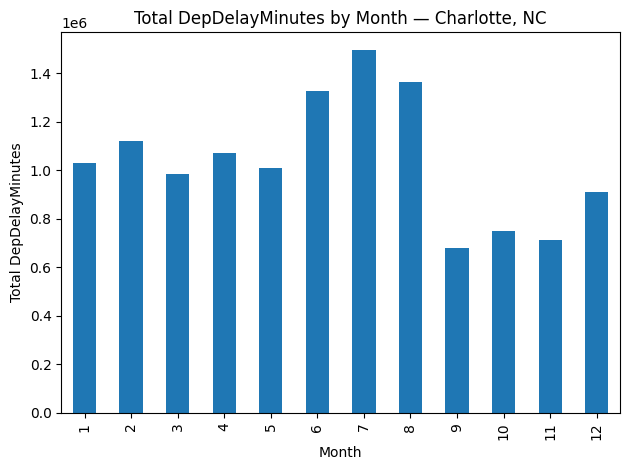

In [7]:
import matplotlib.pyplot as plt

city = 'Charlotte, NC'  # or 'Charlotte. NC'
(df.loc[df['OriginCityName'].eq(city)]
   .groupby('Month')['DepDelayMinutes'].sum()
   .sort_index()
   .plot(kind='bar'))

plt.xlabel('Month'); plt.ylabel('Total DepDelayMinutes')
plt.title(f'Total DepDelayMinutes by Month — {city}')
plt.tight_layout(); plt.show()


In [10]:
df[df['OriginCityName'] == 'Charlotte, NC'].groupby('Marketing_Airline_Network')['DepDelayMinutes'].describe()

,count,mean,std,min,25%,50%,75%,max
Marketing_Airline_Network,,,,,,,,
AA,873214.0,12.620556,40.141659,0.0,0.0,0.0,3.0,1499.0
B6,4180.0,24.628469,62.432191,0.0,0.0,0.0,18.0,960.0
DL,43858.0,12.516052,55.588900,0.0,0.0,0.0,0.0,2710.0
F9,5376.0,21.514137,55.773514,0.0,0.0,0.0,18.0,1124.0
NK,3807.0,26.070659,72.100764,0.0,0.0,0.0,24.0,1452.0
UA,24831.0,16.574806,62.756698,0.0,0.0,0.0,1.0,1393.0
WN,11660.0,12.630617,32.793710,0.0,0.0,0.0,8.0,515.0


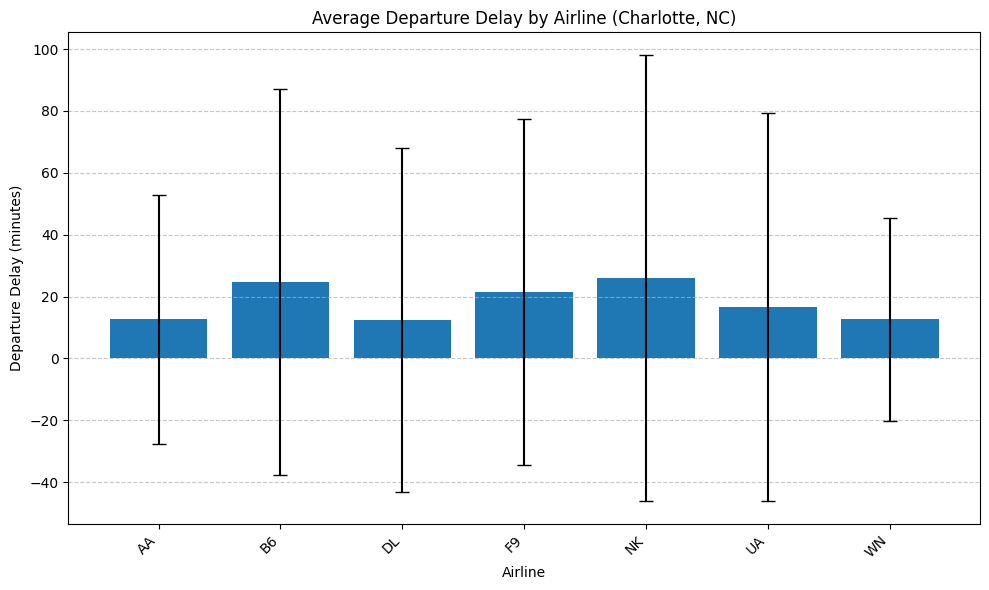

In [11]:
import matplotlib.pyplot as plt

# Compute summary stats
summary = (
    df[df['OriginCityName'] == 'Charlotte, NC']
      .groupby('Marketing_Airline_Network')['DepDelayMinutes']
      .describe()
)

# Plot mean delay with error bars for std deviation
plt.figure(figsize=(10,6))
plt.bar(summary.index, summary['mean'], yerr=summary['std'], capsize=5)
plt.title('Average Departure Delay by Airline (Charlotte, NC)')
plt.ylabel('Departure Delay (minutes)')
plt.xlabel('Airline')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [13]:
# Select using the existing column names
df_continuous = df[
    ['CRSDepTime', 'DepTime', 'DepDelay', 'DepDelayMinutes', 'TaxiOut',
     'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrTime', 'ArrDelay',
     'ArrDelayMinutes', 'CRSElapsedTime', 'ActualElapsedTime', 'AirTime',
     'Distance', 'DistanceGroup', 'CarrierDelay', 'WeatherDelay', 'NASDelay',
     'SecurityDelay', 'LateAircraftDelay']
]



In [14]:
# Correlation matrix only for flights departing from Charlotte, NC
corr_charlotte = (
    df[df['OriginCityName'] == 'Charlotte, NC'][df_continuous.columns]
        .corr()
)

corr_charlotte


,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,TaxiOut,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrTime,...,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
CRSDepTime,1.000000,0.941937,0.103692,0.100389,-0.041029,0.918176,0.689369,0.003618,0.730072,0.646631,...,-0.054132,-0.051185,-0.045682,-0.041050,-0.041591,0.039903,0.040067,0.019091,0.010799,0.087286
DepTime,0.941937,1.000000,0.089168,0.083446,-0.025075,0.973067,0.732851,0.009901,0.711899,0.688979,...,-0.044436,-0.038269,-0.035735,-0.032367,-0.032847,0.016324,0.019749,0.040944,0.014096,0.085633
DepDelay,0.103692,0.089168,1.000000,0.997421,0.012194,0.068396,-0.007481,0.040845,0.081331,-0.013598,...,0.016844,0.028325,0.023120,0.021815,0.022167,0.633102,0.358205,0.219880,0.046127,0.702107
DepDelayMinutes,0.100389,0.083446,0.997421,1.000000,0.013892,0.062969,-0.010127,0.037544,0.078027,-0.016026,...,0.010275,0.021043,0.015723,0.014348,0.014554,0.636672,0.361993,0.214201,0.045031,0.703734
TaxiOut,-0.041029,-0.025075,0.012194,0.013892,1.000000,0.005750,0.005703,0.002848,-0.005516,0.007731,...,-0.053697,0.086984,-0.076903,-0.086957,-0.087042,0.011030,0.039059,0.397566,0.001420,0.004931
WheelsOff,0.918176,0.973067,0.068396,0.062969,0.005750,1.000000,0.757027,0.010166,0.707407,0.713444,...,-0.043424,-0.033181,-0.035669,-0.033045,-0.033411,0.006238,0.015065,0.049652,0.013277,0.067790
WheelsOn,0.689369,0.732851,-0.007481,-0.010127,0.005703,0.757027,1.000000,0.015084,0.754061,0.952914,...,0.010019,0.016784,0.014780,0.014876,0.014074,-0.028088,-0.001730,0.034808,0.004056,0.003369
TaxiIn,0.003618,0.009901,0.040845,0.037544,0.002848,0.010166,0.015084,1.000000,0.014071,0.007725,...,0.166136,0.236155,0.149116,0.143079,0.140812,0.019689,0.011245,0.284110,0.004782,0.022516
CRSArrTime,0.730072,0.711899,0.081331,0.078027,-0.005516,0.707407,0.754061,0.014071,1.000000,0.765740,...,0.004084,0.009244,0.009046,0.009231,0.009590,0.022285,0.035102,0.031669,0.009725,0.071682
ArrTime,0.646631,0.688979,-0.013598,-0.016026,0.007731,0.713444,0.952914,0.007725,0.765740,1.000000,...,0.011491,0.017110,0.015447,0.015028,0.014414,-0.030855,-0.002722,0.030603,0.003509,-0.002358


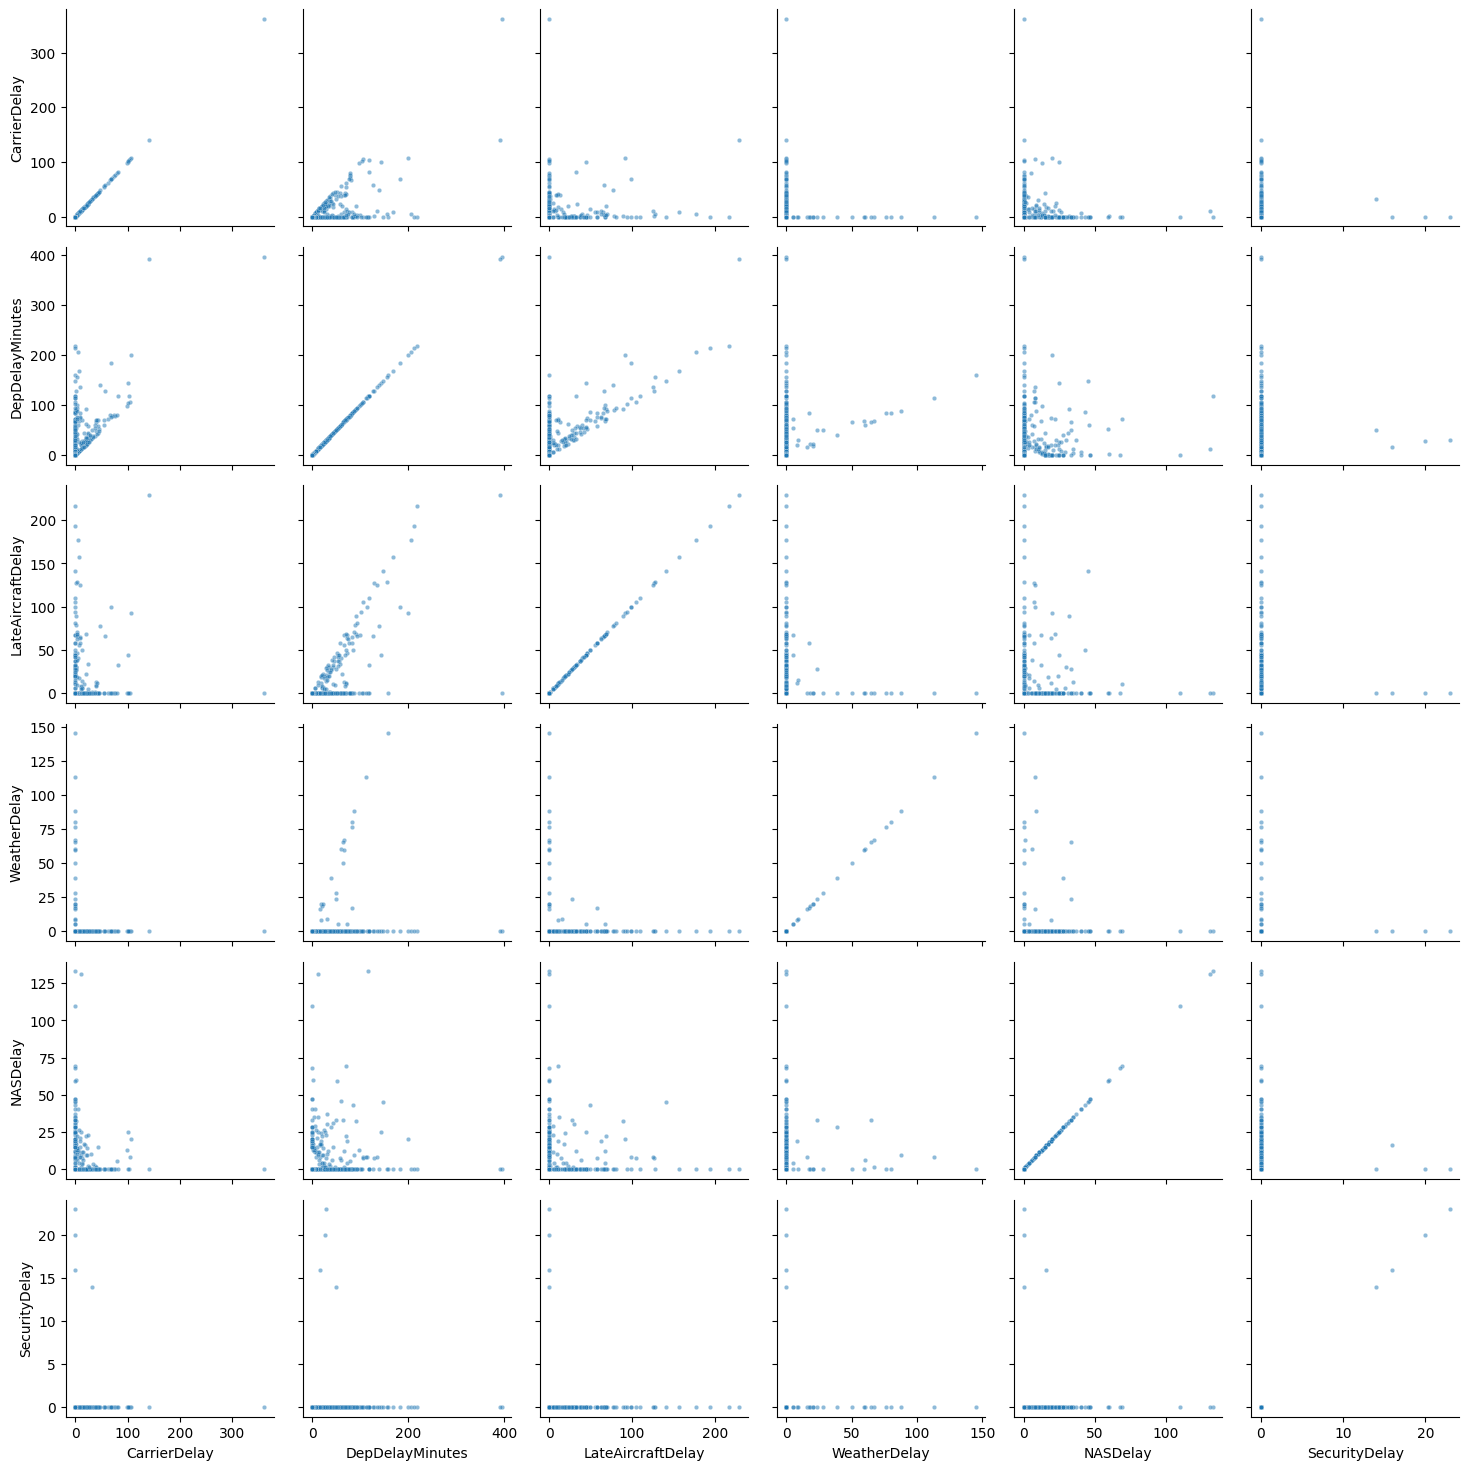

In [15]:
df_use = df[df['OriginCityName'] == 'Charlotte, NC']


# Correct column names from your schema
cols = ["CarrierDelay", "DepDelayMinutes", "LateAircraftDelay",
        "WeatherDelay", "NASDelay", "SecurityDelay"]

# Sample and plot
df_pair = df_use[cols].sample(frac=0.001, random_state=42)

import seaborn as sns
g = sns.PairGrid(df_pair)
g.map(sns.scatterplot, s=10, alpha=0.5)
